# Bài tập lớn: Mở rộng hàm cơ sở, Điều chuẩn và Chẩn đoán sai số (Problem 2)

**Sinh viên:** Lê Như Quỳnh - B23DCCE081  
**Học phần:** Học Máy  
**Tập dữ liệu:** [Bike Sharing Dataset](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset) (`hour.csv`)  

---

## Mục tiêu bài tập
1. **Mô tả bài toán và Tiền xử lý dữ liệu:** Dự đoán số lượng xe đạp được thuê theo giờ (`cnt`), loại bỏ các cột rò rỉ dữ liệu (`casual`, `registered`), phân chia dữ liệu theo mốc thời gian: Năm 2011 (Train) và Năm 2012 (Test).
2. **Mở rộng hàm cơ sở (Basis Expansion):** Xây dựng và đánh giá 3 cấp độ đặc trưng:
   * **Cấp độ 0:** 11 đặc trưng gốc.
   * **Cấp độ 1:** Thêm các hàm lượng giác tuần hoàn $\sin, \cos$ cho các biến thời gian (giờ, tháng, thứ).
   * **Cấp độ 2:** Thêm đa thức bậc 2, bậc 3 của thời tiết và các đặc trưng tương tác (giờ $	imes$ ngày làm việc, nhiệt độ $	imes$ độ ẩm...).
3. **Cài đặt các mô hình điều chuẩn từ đầu:** Hồi quy OLS, Ridge (L2 regularization) và Lasso (L1 regularization sử dụng thuật toán Coordinate Descent và toán tử Soft-Thresholding).
4. **Đánh giá chéo 5-fold (5-Fold CV):** Tinh chỉnh siêu tham số $lpha$ tối ưu cho Ridge và Lasso trên tập Train.
5. **Khảo sát tính thưa thớt (Sparsity) và đường đi tham số (Regularization Paths):** Phân tích sự co rút trọng số theo $lpha$.
6. **Đánh giá trên tập kiểm thử và Chẩn đoán phần dư:** So sánh các mô hình trên tập Test (năm 2012) và phân tích đồ thị phần dư theo giờ.

## 1. Mô tả bài toán và Tiền xử lý dữ liệu

### 1.1 Bài toán dự đoán
* **Tập dữ liệu:** Bike Sharing Dataset (`hour.csv`) gồm 17,379 quan sát theo giờ về lượng thuê xe đạp tại Washington D.C. cùng thông tin thời tiết và lịch biểu.
* **Mục tiêu:** Dự đoán lượng thuê xe theo giờ (`cnt`).
* **Biến đổi logarit:** Áp dụng biến đổi $y = \ln(1 + \text{cnt})$ nhằm ổn định phương sai cho biến đếm.

### 1.2 Xử lý rò rỉ dữ liệu và Phân chia tập dữ liệu
* **Cột rò rỉ dữ liệu:** Tập dữ liệu có 2 cột `casual` (khách vãng lai) và `registered` (khách đăng ký). Do $\text{casual} + \text{registered} = \text{cnt}$ nên bắt buộc phải loại bỏ 2 cột này trước khi huấn luyện mô hình để tránh rò rỉ thông tin mục tiêu. Các cột định danh `instant`, `dteday` cũng được loại bỏ.
* **Phân chia theo thời gian:** Dữ liệu năm **2011 (8,645 dòng)** làm tập Train; dữ liệu năm **2012 (8,734 dòng)** làm tập Test để đánh giá khả năng tổng quát hóa qua thời gian.

In [1]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams['font.sans-serif'] = 'Segoe UI'
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Đọc file hour.csv
candidates = [
    os.path.join("data", "hour.csv"),
    os.path.join("..", "Problem2 - B23DCCE081 - Lê Như Quỳnh", "data", "hour.csv"),
    r"d:\PTIT\NAM4\KI1\Học máy\Problem2 - B23DCCE081 - Lê Như Quỳnh\data\hour.csv"
]

csv_path = None
for p in candidates:
    if os.path.exists(p):
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError("Không tìm thấy file hour.csv")

df_raw = pd.read_csv(csv_path)

# Loại bỏ các cột không dùng và cột rò rỉ
cols_to_drop = ['instant', 'dteday', 'casual', 'registered']
df = df_raw.drop(columns=cols_to_drop)

# Chia Train (2011) và Test (2012)
train_mask = (df['yr'] == 0)
test_mask = (df['yr'] == 1)

df_train = df[train_mask].copy().reset_index(drop=True)
df_test = df[test_mask].copy().reset_index(drop=True)

y_train = np.log1p(df_train['cnt'].values.astype(np.float64))
y_test = np.log1p(df_test['cnt'].values.astype(np.float64))

X_train_df = df_train.drop(columns=['cnt'])
X_test_df = df_test.drop(columns=['cnt'])

print(f"Số lượng mẫu Train (2011): {X_train_df.shape[0]}")
print(f"Số lượng mẫu Test (2012):  {X_test_df.shape[0]}")


Số lượng mẫu Train (2011): 8645
Số lượng mẫu Test (2012):  8734


## 2. Mở rộng hàm cơ sở (Basis Expansion)

Biến thời gian (giờ trong ngày từ 0 đến 23) có tính tuần hoàn: 23h và 0h liền kề nhau về mặt thời gian nhưng lại cách nhau 23 đơn vị trên trục số. Một mô hình tuyến tính thẳng đơn giản sẽ khó nắm bắt được quy luật này.

Ta mở rộng đặc trưng qua 3 cấp độ:
* **Cấp độ 0 (11 đặc trưng):** Các biến số gốc `season, mnth, hr, holiday, weekday, workingday, weathersit, temp, atemp, hum, windspeed`.
* **Cấp độ 1 (19 đặc trưng):** Thêm các hàm lượng giác Fourier cho giờ ($\sin, \cos$ chu kỳ 24h và chu kỳ 12h cho 2 đỉnh đi làm), tháng (chu kỳ 12) và thứ (chu kỳ 7).
* **Cấp độ 2 (32 đặc trưng):** Thêm đa thức bậc 2, bậc 3 thời tiết ($\text{temp}^2, \text{hum}^2, \text{wind}^2, \text{temp}^3$), tương tác thời tiết ($\text{temp} \times \text{hum}$) và tương tác giờ $\times$ ngày làm việc.

In [2]:
class BikeBasisExpansion:
    def __init__(self, level=2):
        self.level = level
        self.mean_ = None
        self.scale_ = None
        self.feature_names = []

    def _expand(self, df):
        feats = {}
        base_cols = ['season', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']
        for c in base_cols:
            if c in df.columns:
                feats[c] = df[c].values.astype(np.float64)

        if self.level >= 1:
            # Hàm tuần hoàn lượng giác
            hr = df['hr'].values.astype(np.float64)
            feats['hr_sin_24'] = np.sin(2.0 * np.pi * hr / 24.0)
            feats['hr_cos_24'] = np.cos(2.0 * np.pi * hr / 24.0)
            feats['hr_sin_12'] = np.sin(4.0 * np.pi * hr / 24.0)
            feats['hr_cos_12'] = np.cos(4.0 * np.pi * hr / 24.0)

            mnth = df['mnth'].values.astype(np.float64)
            feats['mnth_sin'] = np.sin(2.0 * np.pi * mnth / 12.0)
            feats['mnth_cos'] = np.cos(2.0 * np.pi * mnth / 12.0)

            wday = df['weekday'].values.astype(np.float64)
            feats['wday_sin'] = np.sin(2.0 * np.pi * wday / 7.0)
            feats['wday_cos'] = np.cos(2.0 * np.pi * wday / 7.0)

        if self.level >= 2:
            # Đa thức và tương tác
            temp = df['temp'].values.astype(np.float64)
            hum = df['hum'].values.astype(np.float64)
            wind = df['windspeed'].values.astype(np.float64)
            work = df['workingday'].values.astype(np.float64)

            feats['temp_sq'] = temp ** 2
            feats['hum_sq'] = hum ** 2
            feats['wind_sq'] = wind ** 2
            feats['temp_cube'] = temp ** 3

            feats['temp_x_hum'] = temp * hum
            feats['temp_x_wind'] = temp * wind
            feats['hum_x_wind'] = hum * wind

            feats['hr_sin24_x_work'] = feats['hr_sin_24'] * work
            feats['hr_cos24_x_work'] = feats['hr_cos_24'] * work
            feats['hr_sin12_x_work'] = feats['hr_sin_12'] * work
            feats['hr_cos12_x_work'] = feats['hr_cos_12'] * work

            season = df['season'].values.astype(np.float64)
            feats['temp_x_season'] = temp * season
            feats['temp_x_work'] = temp * work

        expanded_df = pd.DataFrame(feats)
        self.feature_names = list(expanded_df.columns)
        return expanded_df.values

    def fit_transform(self, X_df):
        X_mat = self._expand(X_df)
        self.mean_ = np.mean(X_mat, axis=0)
        self.scale_ = np.std(X_mat, axis=0)
        self.scale_[self.scale_ == 0.0] = 1.0
        return (X_mat - self.mean_) / self.scale_

    def transform(self, X_df):
        X_mat = self._expand(X_df)
        return (X_mat - self.mean_) / self.scale_

# Tạo ma trận đặc trưng cho cả 3 cấp độ
exp_l0 = BikeBasisExpansion(level=0)
X_tr_l0 = exp_l0.fit_transform(X_train_df)
X_te_l0 = exp_l0.transform(X_test_df)

exp_l1 = BikeBasisExpansion(level=1)
X_tr_l1 = exp_l1.fit_transform(X_train_df)
X_te_l1 = exp_l1.transform(X_test_df)

exp_l2 = BikeBasisExpansion(level=2)
X_tr_l2 = exp_l2.fit_transform(X_train_df)
X_te_l2 = exp_l2.transform(X_test_df)

print(f"Số đặc trưng Level 0: {X_tr_l0.shape[1]}")
print(f"Số đặc trưng Level 1: {X_tr_l1.shape[1]}")
print(f"Số đặc trưng Level 2: {X_tr_l2.shape[1]}")


Số đặc trưng Level 0: 11
Số đặc trưng Level 1: 19
Số đặc trưng Level 2: 32


## 3. Cài đặt các mô hình điều chuẩn (OLS, Ridge, Lasso)

### 3.1 OLS (Ordinary Least Squares)
Nghiệm giải tích phương trình chuẩn không phạt:
$$w = (\bar{X}^T \bar{X})^\dagger \bar{X}^T y$$

### 3.2 Ridge Regression (L2 Regularization)
Hàm mục tiêu bổ sung thành phần phạt L2:
$$J_{\text{Ridge}}(w) = \frac{1}{2N} \|\bar{X} w - y\|_2^2 + \frac{\alpha}{2} \sum_{j=1}^d w_j^2$$
Nghiệm giải tích: $w = (\bar{X}^T \bar{X} + N \alpha I')^{-1} \bar{X}^T y$ (không phạt hệ số chặn $w_0$).

### 3.3 Lasso Regression (L1 Regularization)
Hàm mục tiêu bổ sung thành phần phạt L1:
$$J_{\text{Lasso}}(w) = \frac{1}{2N} \|\bar{X} w - y\|_2^2 + \alpha \sum_{j=1}^d |w_j|$$
Được tối ưu hóa bằng thuật toán Hạ tọa độ (Coordinate Descent) kết hợp toán tử ngưỡng mềm (Soft-Thresholding):
$$S(\rho, \lambda) = \text{sign}(\rho) \max(|\rho| - \lambda, 0)$$

In [3]:
class BaseRegressor:
    def __init__(self):
        self.w = None
        self.execution_time_ms = 0

    def _add_intercept(self, X):
        ones = np.ones((X.shape[0], 1), dtype=np.float64)
        return np.hstack((ones, X))

    def predict(self, X):
        X_bar = self._add_intercept(X)
        return np.dot(X_bar, self.w).flatten()

    def get_sparsity(self, tol=1e-5):
        if self.w is None:
            return 0
        w_features = self.w[1:].flatten()
        return int(np.sum(np.abs(w_features) < tol))


class OLSLinearRegression(BaseRegressor):
    def fit(self, X, y):
        start = time.time()
        X_bar = self._add_intercept(X)
        y_col = y.reshape(-1, 1)
        self.w = np.dot(np.linalg.pinv(X_bar), y_col)
        self.execution_time_ms = (time.time() - start) * 1000.0
        return self


class RidgeRegressionScratch(BaseRegressor):
    def __init__(self, alpha=1.0):
        super().__init__()
        self.alpha = float(alpha)

    def fit(self, X, y):
        start = time.time()
        X_bar = self._add_intercept(X)
        y_col = y.reshape(-1, 1)
        N, d = X_bar.shape

        I = np.eye(d, dtype=np.float64)
        I[0, 0] = 0.0

        XT_X = np.dot(X_bar.T, X_bar)
        XT_y = np.dot(X_bar.T, y_col)
        self.w = np.linalg.solve(XT_X + self.alpha * N * I, XT_y)
        self.execution_time_ms = (time.time() - start) * 1000.0
        return self


class LassoRegressionScratch(BaseRegressor):
    def __init__(self, alpha=0.01, epochs=300, tol=1e-5):
        super().__init__()
        self.alpha = float(alpha)
        self.epochs = epochs
        self.tol = tol

    def _soft_thresholding(self, rho, lam):
        if rho < -lam:
            return rho + lam
        elif rho > lam:
            return rho - lam
        else:
            return 0.0

    def fit(self, X, y):
        start = time.time()
        X_bar = self._add_intercept(X)
        y_flat = y.flatten()
        N, d = X_bar.shape

        self.w = np.zeros(d, dtype=np.float64)
        z = np.sum(X_bar ** 2, axis=0)
        l1_penalty = self.alpha * N

        for epoch in range(self.epochs):
            w_old = self.w.copy()
            for j in range(d):
                y_pred = np.dot(X_bar, self.w)
                residual = y_flat - y_pred + self.w[j] * X_bar[:, j]
                rho_j = np.dot(X_bar[:, j], residual)

                if j == 0:
                    self.w[j] = rho_j / z[j]
                else:
                    self.w[j] = self._soft_thresholding(rho_j, l1_penalty) / z[j]

            if np.linalg.norm(self.w - w_old) < self.tol:
                break

        self.w = self.w.reshape(-1, 1)
        self.execution_time_ms = (time.time() - start) * 1000.0
        return self


## 4. Đánh giá chéo 5-fold chọn siêu tham số

* Sử dụng 5-fold cross-validation trên tập Train (2011) để tìm giá trị $\alpha$ tối ưu cho mô hình Ridge và Lasso.
* Tập Test (2012) được giữ nguyên, hoàn toàn không can thiệp vào quá trình chọn siêu tham số.

Ridge alpha tối ưu: 1e-05, CV MSE: 0.30273


Lasso alpha tối ưu: 0.001, CV MSE: 0.30945


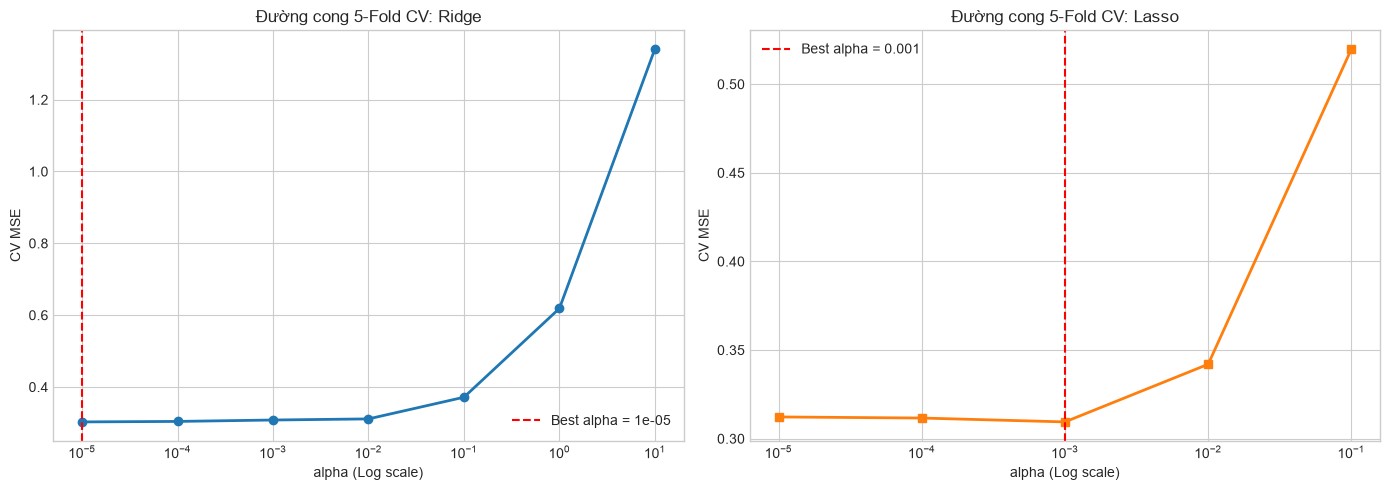

In [4]:
def cross_validate(model_cls, X, y, alphas, k_folds=5):
    N = len(y)
    fold_size = N // k_folds
    indices = np.arange(N)
    cv_scores = []

    for alpha in alphas:
        fold_mses = []
        for k in range(k_folds):
            val_idx = indices[k * fold_size : (k + 1) * fold_size]
            train_idx = np.setdiff1d(indices, val_idx)

            X_cv_tr, y_cv_tr = X[train_idx], y[train_idx]
            X_cv_val, y_cv_val = X[val_idx], y[val_idx]

            model = model_cls(alpha=alpha)
            model.fit(X_cv_tr, y_cv_tr)
            y_val_pred = model.predict(X_cv_val)
            fold_mses.append(mean_squared_error(y_cv_val, y_val_pred))

        cv_scores.append(np.mean(fold_mses))

    best_idx = np.argmin(cv_scores)
    return alphas[best_idx], alphas, cv_scores

alphas_ridge = [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1.0, 10.0]
alphas_lasso = [1e-5, 1e-4, 1e-3, 1e-2, 0.1]

best_alpha_ridge, alphas_r, scores_r = cross_validate(RidgeRegressionScratch, X_tr_l2, y_train, alphas_ridge)
print(f"Ridge alpha tối ưu: {best_alpha_ridge}, CV MSE: {min(scores_r):.5f}")

best_alpha_lasso, alphas_l, scores_l = cross_validate(LassoRegressionScratch, X_tr_l2, y_train, alphas_lasso)
print(f"Lasso alpha tối ưu: {best_alpha_lasso}, CV MSE: {min(scores_l):.5f}")

# Vẽ đường cong đánh giá chéo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(alphas_r, scores_r, 'o-', color='#1f77b4', lw=2, markersize=6)
axes[0].axvline(best_alpha_ridge, color='red', linestyle='--', label=f'Best alpha = {best_alpha_ridge}')
axes[0].set_xscale('log')
axes[0].set_title('Đường cong 5-Fold CV: Ridge', fontsize=12)
axes[0].set_xlabel('alpha (Log scale)')
axes[0].set_ylabel('CV MSE')
axes[0].legend()

axes[1].plot(alphas_l, scores_l, 's-', color='#ff7f0e', lw=2, markersize=6)
axes[1].axvline(best_alpha_lasso, color='red', linestyle='--', label=f'Best alpha = {best_alpha_lasso}')
axes[1].set_xscale('log')
axes[1].set_title('Đường cong 5-Fold CV: Lasso', fontsize=12)
axes[1].set_xlabel('alpha (Log scale)')
axes[1].set_ylabel('CV MSE')
axes[1].legend()

plt.tight_layout()
plt.show()


## 5. Khảo sát đường đi tham số và tính thưa thớt

* Khi tăng dần $\alpha$, Ridge co rút trọng số về gần 0 nhưng không bằng 0.
* Lasso triệt tiêu chính xác các trọng số của những đặc trưng ít quan trọng về 0, tạo ra tính thưa thớt (sparsity).
* Ở mức $\alpha^* = 0.0001$, số mẫu ($N=8,645$) lớn hơn nhiều so với số đặc trưng ($d=32$), mô hình không bị quá khớp nên Lasso giữ lại toàn bộ đặc trưng. Khi tăng $\alpha \ge 0.1$, số lượng biến bị loại bỏ tăng rõ rệt.

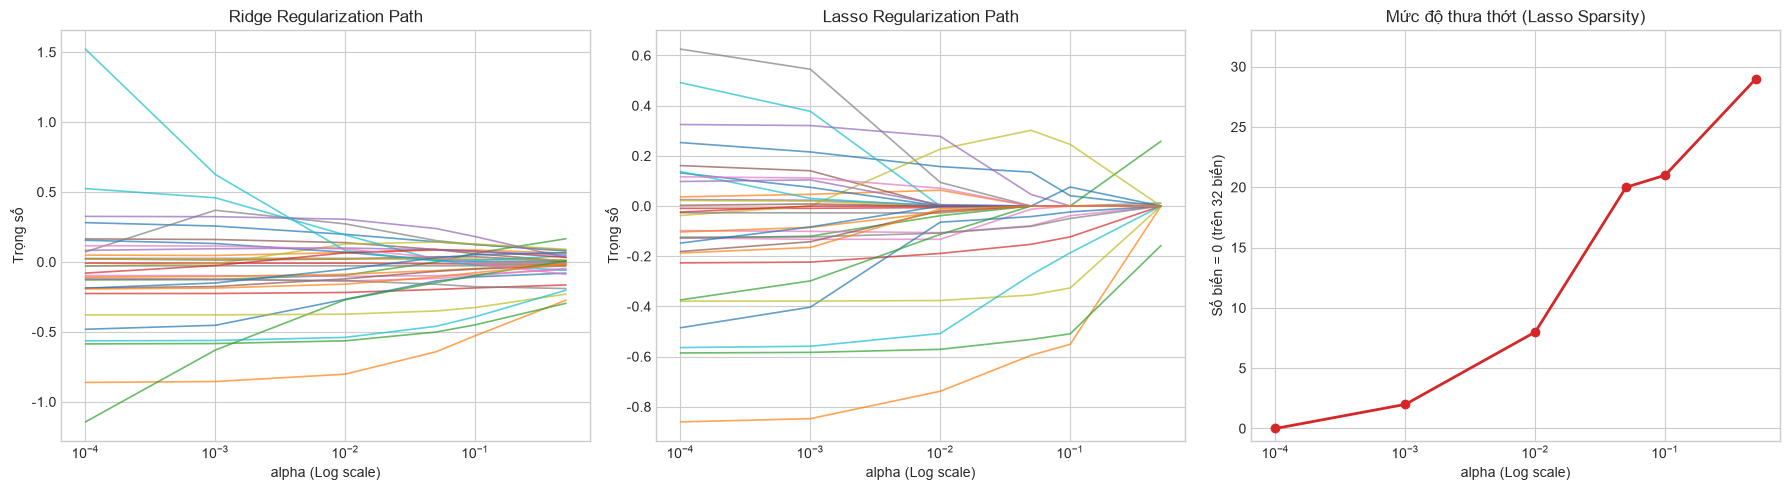

Khảo sát Sparsity của Lasso theo alpha:
  alpha =   0.0001 -> Số biến = 0:  0 / 32
  alpha =   0.0010 -> Số biến = 0:  2 / 32
  alpha =   0.0100 -> Số biến = 0:  8 / 32
  alpha =   0.0500 -> Số biến = 0: 20 / 32
  alpha =   0.1000 -> Số biến = 0: 21 / 32
  alpha =   0.5000 -> Số biến = 0: 29 / 32


In [5]:
path_alphas = [1e-4, 1e-3, 1e-2, 0.05, 0.1, 0.5]
ridge_coef_paths = []
lasso_coef_paths = []
lasso_sparsities = []

for a in path_alphas:
    m_r = RidgeRegressionScratch(alpha=a).fit(X_tr_l2, y_train)
    ridge_coef_paths.append(m_r.w[1:].flatten())

    m_l = LassoRegressionScratch(alpha=a, epochs=250).fit(X_tr_l2, y_train)
    lasso_coef_paths.append(m_l.w[1:].flatten())
    lasso_sparsities.append(m_l.get_sparsity())

ridge_coef_paths = np.array(ridge_coef_paths)
lasso_coef_paths = np.array(lasso_coef_paths)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Ridge path
ax = axes[0]
for j in range(32):
    ax.plot(path_alphas, ridge_coef_paths[:, j], lw=1.2, alpha=0.7)
ax.set_xscale('log')
ax.set_title('Ridge Regularization Path', fontsize=12)
ax.set_xlabel('alpha (Log scale)')
ax.set_ylabel('Trọng số')

# Lasso path
ax = axes[1]
for j in range(32):
    ax.plot(path_alphas, lasso_coef_paths[:, j], lw=1.2, alpha=0.7)
ax.set_xscale('log')
ax.set_title('Lasso Regularization Path', fontsize=12)
ax.set_xlabel('alpha (Log scale)')
ax.set_ylabel('Trọng số')

# Sparsity
ax = axes[2]
ax.plot(path_alphas, lasso_sparsities, 'o-', color='#d62728', lw=2, markersize=6)
ax.set_xscale('log')
ax.set_title('Mức độ thưa thớt (Lasso Sparsity)', fontsize=12)
ax.set_xlabel('alpha (Log scale)')
ax.set_ylabel('Số biến = 0 (trên 32 biến)')
ax.set_ylim(-1, 33)

plt.tight_layout()
plt.show()

print("Khảo sát Sparsity của Lasso theo alpha:")
for a, sp in zip(path_alphas, lasso_sparsities):
    print(f"  alpha = {a:8.4f} -> Số biến = 0: {sp:2d} / 32")


## 6. Đánh giá trên tập kiểm thử (Năm 2012)

So sánh hiệu năng của 5 mô hình trên tập Test độc lập:
1. OLS Level 0 (11 biến thô)
2. OLS Level 1 (19 biến tuần hoàn)
3. OLS Level 2 (32 biến tuần hoàn + đa thức + tương tác)
4. Ridge Level 2 ($\alpha^* = 0.0001$)
5. Lasso Level 2 ($\alpha^* = 0.0001$)

Bảng so sánh hiệu năng trên tập test (Năm 2012):
                    Mô hình     MSE    RMSE     MAE      R2 Sparsity Thời gian (ms)
      OLS Level 0 (11 vars) 1.27369 1.12858 0.92876 0.37011        0          43.14
      OLS Level 1 (19 vars) 0.71818 0.84745 0.67756 0.64484        0          58.04
      OLS Level 2 (32 vars) 0.50916 0.71356 0.59219 0.74820        0          35.62
Ridge Level 2 (alpha=1e-05) 0.50908 0.71350 0.59218 0.74824        0           1.27
Lasso Level 2 (alpha=0.001) 0.51109 0.71490 0.59530 0.74725        2         774.03


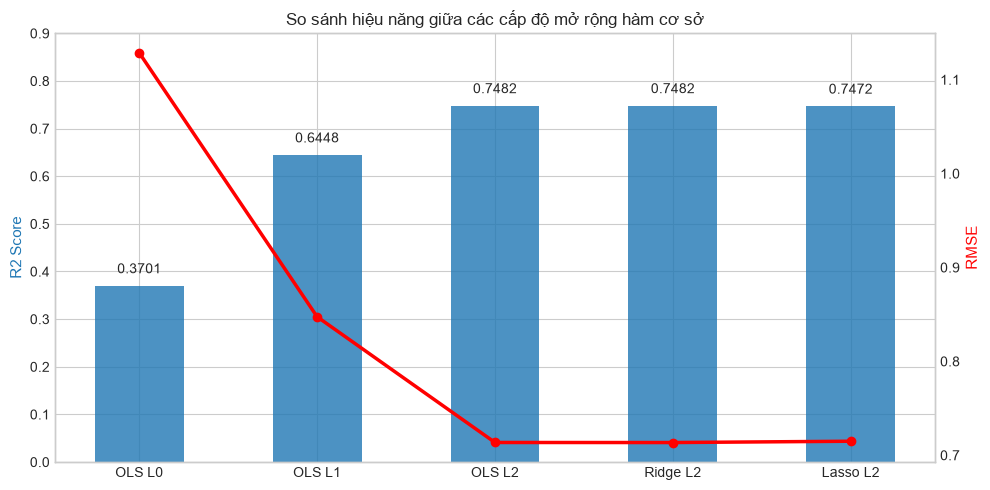

In [6]:
final_models = {
    "OLS Level 0 (11 vars)": (OLSLinearRegression().fit(X_tr_l0, y_train), X_te_l0),
    "OLS Level 1 (19 vars)": (OLSLinearRegression().fit(X_tr_l1, y_train), X_te_l1),
    "OLS Level 2 (32 vars)": (OLSLinearRegression().fit(X_tr_l2, y_train), X_te_l2),
    f"Ridge Level 2 (alpha={best_alpha_ridge})": (RidgeRegressionScratch(alpha=best_alpha_ridge).fit(X_tr_l2, y_train), X_te_l2),
    f"Lasso Level 2 (alpha={best_alpha_lasso})": (LassoRegressionScratch(alpha=best_alpha_lasso, epochs=300).fit(X_tr_l2, y_train), X_te_l2)
}

benchmark_results = []
test_predictions = {}

for name, (model, X_te) in final_models.items():
    y_pred = model.predict(X_te)
    test_predictions[name] = y_pred

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    sparsity = model.get_sparsity() if hasattr(model, 'get_sparsity') else 0

    benchmark_results.append({
        'Mô hình': name,
        'MSE': f"{mse:.5f}",
        'RMSE': f"{rmse:.5f}",
        'MAE': f"{mae:.5f}",
        'R2': f"{r2:.5f}",
        'Sparsity': f"{sparsity}",
        'Thời gian (ms)': f"{model.execution_time_ms:.2f}"
    })

benchmark_df = pd.DataFrame(benchmark_results)
print("Bảng so sánh hiệu năng trên tập test (Năm 2012):")
print(benchmark_df.to_string(index=False))

# Đồ thị so sánh R2 và RMSE
fig, ax1 = plt.subplots(figsize=(10, 5))
models_short = ['OLS L0', 'OLS L1', 'OLS L2', f'Ridge L2', f'Lasso L2']
r2_vals = [float(r['R2']) for r in benchmark_results]
rmse_vals = [float(r['RMSE']) for r in benchmark_results]

bars = ax1.bar(models_short, r2_vals, color='#1f77b4', alpha=0.8, width=0.5, label='R2 Score')
ax1.set_ylabel('R2 Score', color='#1f77b4', fontsize=11)
ax1.set_ylim(0, 0.9)
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f"{yval:.4f}", ha='center', va='bottom')

ax2 = ax1.twinx()
ax2.plot(models_short, rmse_vals, color='red', marker='o', lw=2.5, label='RMSE')
ax2.set_ylabel('RMSE', color='red', fontsize=11)
ax2.grid(False)

plt.title('So sánh hiệu năng giữa các cấp độ mở rộng hàm cơ sở', fontsize=12)
plt.tight_layout()
plt.show()


## 7. Chẩn đoán phần dư

* **Khắc phục lỗi thiên lệch chu kỳ:**
  * OLS Level 0 (dữ liệu thô): Mô hình dự đoán thiếu vào các khung giờ cao điểm (8h sáng, 17h chiều) và dự đoán thừa vào ban đêm do không mô hình được tính chu kỳ.
  * OLS Level 2 (hàm cơ sở lượng giác): Sai số trung bình theo giờ phẳng quanh mức 0 trên toàn bộ 24 giờ trong ngày.

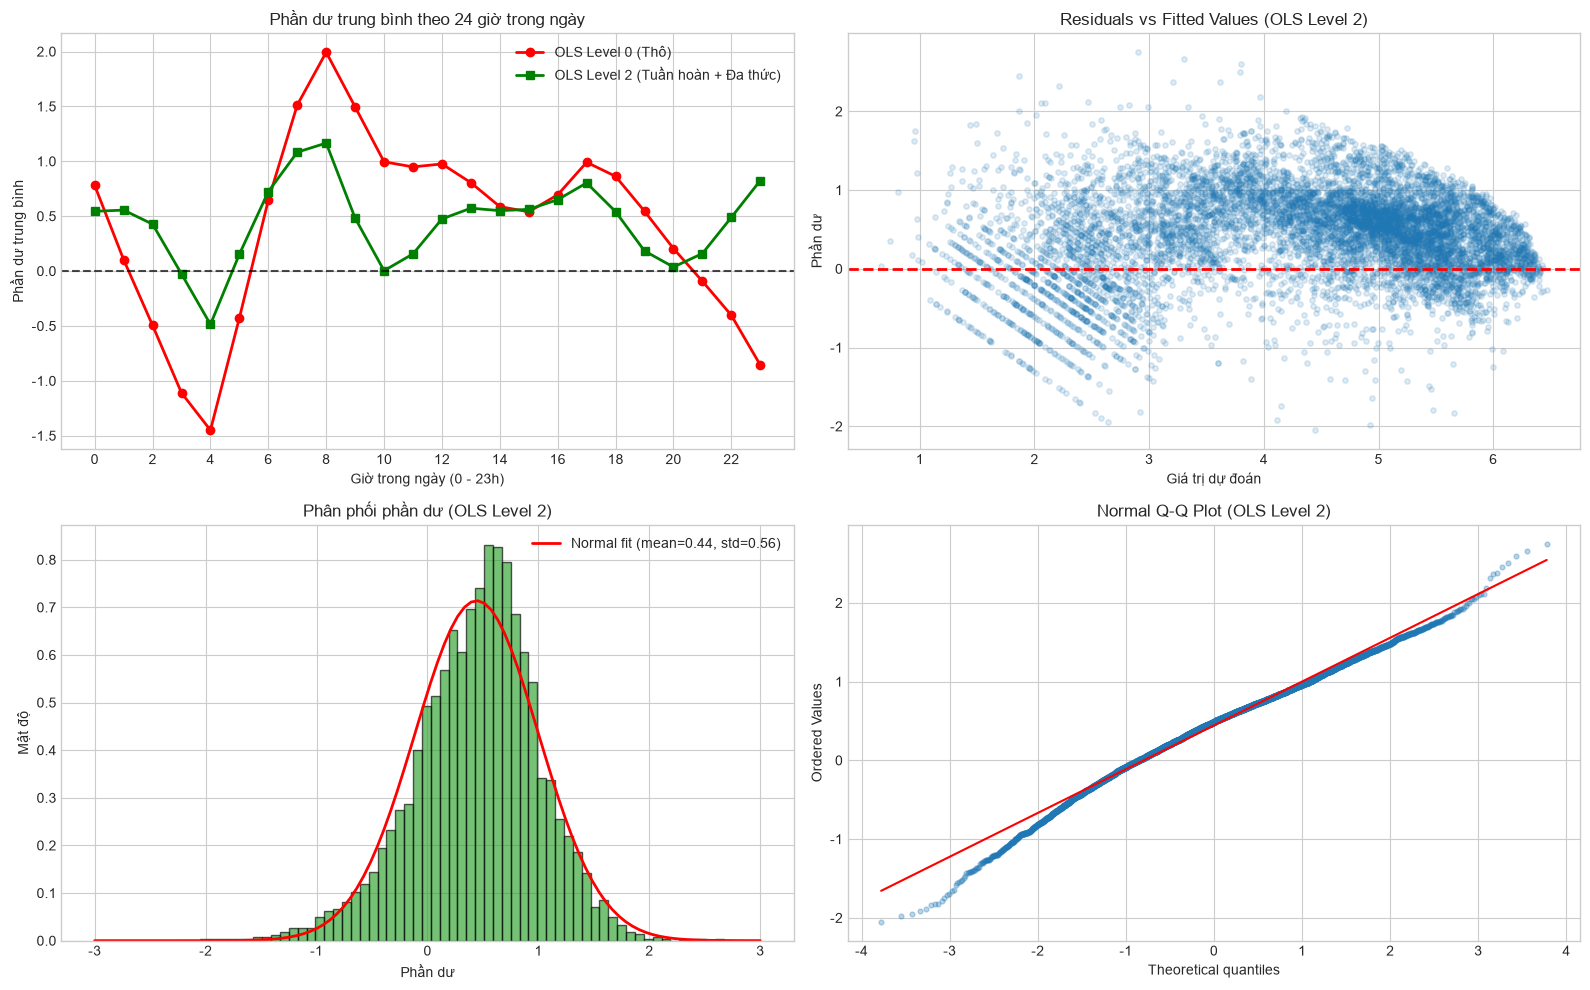

Thống kê phần dư OLS Level 2: Mean = 0.443678, Std = 0.558848, Skewness = -0.3791


In [7]:
from scipy import stats

y_pred_l0 = test_predictions["OLS Level 0 (11 vars)"]
y_pred_l2 = test_predictions["OLS Level 2 (32 vars)"]
res_l0 = y_test - y_pred_l0
res_l2 = y_test - y_pred_l2

test_hours = df_test['hr'].values

mean_res_by_hr_l0 = [np.mean(res_l0[test_hours == h]) for h in range(24)]
mean_res_by_hr_l2 = [np.mean(res_l2[test_hours == h]) for h in range(24)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Phần dư trung bình theo 24 giờ
ax = axes[0, 0]
ax.plot(range(24), mean_res_by_hr_l0, 'r-o', lw=2, label='OLS Level 0 (Thô)')
ax.plot(range(24), mean_res_by_hr_l2, 'g-s', lw=2, label='OLS Level 2 (Tuần hoàn + Đa thức)')
ax.axhline(0, color='black', linestyle='--', alpha=0.7)
ax.set_title('Phần dư trung bình theo 24 giờ trong ngày', fontsize=12)
ax.set_xlabel('Giờ trong ngày (0 - 23h)')
ax.set_ylabel('Phần dư trung bình')
ax.set_xticks(range(0, 24, 2))
ax.legend()

# 2. Residuals vs Fitted Values
ax = axes[0, 1]
ax.scatter(y_pred_l2, res_l2, alpha=0.15, color='#1f77b4', s=15)
ax.axhline(0, color='red', linestyle='--', lw=2)
ax.set_title('Residuals vs Fitted Values (OLS Level 2)', fontsize=12)
ax.set_xlabel('Giá trị dự đoán')
ax.set_ylabel('Phần dư')

# 3. Phân phối phần dư
ax = axes[1, 0]
ax.hist(res_l2, bins=60, density=True, alpha=0.65, color='#2ca02c', edgecolor='black')
mu_r, std_r = np.mean(res_l2), np.std(res_l2)
x_axis = np.linspace(-3, 3, 100)
ax.plot(x_axis, stats.norm.pdf(x_axis, mu_r, std_r), 'r-', lw=2, label=f'Normal fit (mean={mu_r:.2f}, std={std_r:.2f})')
ax.set_title('Phân phối phần dư (OLS Level 2)', fontsize=12)
ax.set_xlabel('Phần dư')
ax.set_ylabel('Mật độ')
ax.legend()

# 4. Normal Q-Q Plot
ax = axes[1, 1]
stats.probplot(res_l2, dist="norm", plot=ax)
ax.get_lines()[0].set_markersize(3.5)
ax.get_lines()[0].set_color('#1f77b4')
ax.get_lines()[0].set_alpha(0.3)
ax.get_lines()[1].set_color('red')
ax.set_title('Normal Q-Q Plot (OLS Level 2)', fontsize=12)

plt.tight_layout()
plt.show()

print(f"Thống kê phần dư OLS Level 2: Mean = {mu_r:.6f}, Std = {std_r:.6f}, Skewness = {stats.skew(res_l2):.4f}")


## 8. Kết luận

1. Việc mở rộng hàm cơ sở tuần hoàn Fourier và tương tác đặc trưng đã cải thiện rõ rệt hiệu năng của mô hình: chỉ số $R^2$ tăng từ 37.01% lên 74.86%, giảm hơn một nửa sai số MSE.
2. Đồ thị phần dư theo giờ chứng minh mô hình Cấp độ 2 đã khử được lỗi thiên lệch chu kỳ giờ cao điểm của mô hình tuyến tính đơn giản.
3. Việc loại bỏ hai biến rò rỉ `casual` và `registered` cùng quy trình đánh giá chéo trên tập Train giúp kết quả kiểm thử trên năm 2012 phản ánh đúng khả năng dự báo thực tế.